# 02 Exploratory Data Analysis

Explore the cleaned weather dataset with reusable visualizations and save a few key figures.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GlobalWeatherRepository.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.preprocessing import get_numeric_columns, load_processed_data
from src.visualize import (
    plot_air_quality_distributions,
    plot_correlation_heatmap,
    plot_missing_values_heatmap,
    plot_numeric_distributions,
    plot_temperature_vs_feels_like,
    save_figure,
)


In [3]:
clean_data_path = PROCESSED_DIR / "clean_weather_data.csv"
df = load_processed_data(clean_data_path)

print(f"Loaded cleaned data from: {clean_data_path}")
print(f"Shape: {df.shape}")
display(df.head())
display(df.describe(include="all").transpose().head(15))


Loaded cleaned data from: D:\Projects 2025\weather-forecasting-eda-ml\data\processed\clean_weather_data.csv
Shape: (137413, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,Clear,...,6.3,7.1,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,Partly cloudy,...,19.0,25.3,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,Moderate or heavy rain with thunder,...,20.4,28.1,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,Mist,...,132.0,178.1,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,Overcast,...,7.7,32.1,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
country,137413,211,Bulgaria,1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,137413,257,Accra,707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,137413.0,NaN,NaN,NaN,19.211977,-41.3,4.0503,17.25,40.4,64.15,24.415352
longitude,137413.0,NaN,NaN,NaN,21.95408,-175.2,-6.8361,23.2361,49.8822,179.22,65.786759
timezone,137413,199,Asia/Bangkok,2529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,137413.0,NaN,NaN,NaN,1746429306.313813,1715849100.0,1731228300.0,1746435600.0,1761638400.0,1777012200.0,17649220.760583
last_updated,137413,NaN,NaN,NaN,2025-05-05 09:24:19.486366,2024-05-16 01:45:00,2024-11-10 05:00:00,2025-05-05 11:00:00,2025-10-28 14:30:00,2026-04-24 19:30:00,NaN
temperature_celsius,137413.0,NaN,NaN,NaN,21.259542,-29.8,15.8,23.9,28.0,79.3,9.683796
temperature_fahrenheit,137413.0,NaN,NaN,NaN,70.268958,-21.6,60.5,75.0,82.4,174.7,17.430696
condition_text,137413,49,Partly cloudy,39542,NaN,NaN,NaN,NaN,NaN,NaN,NaN


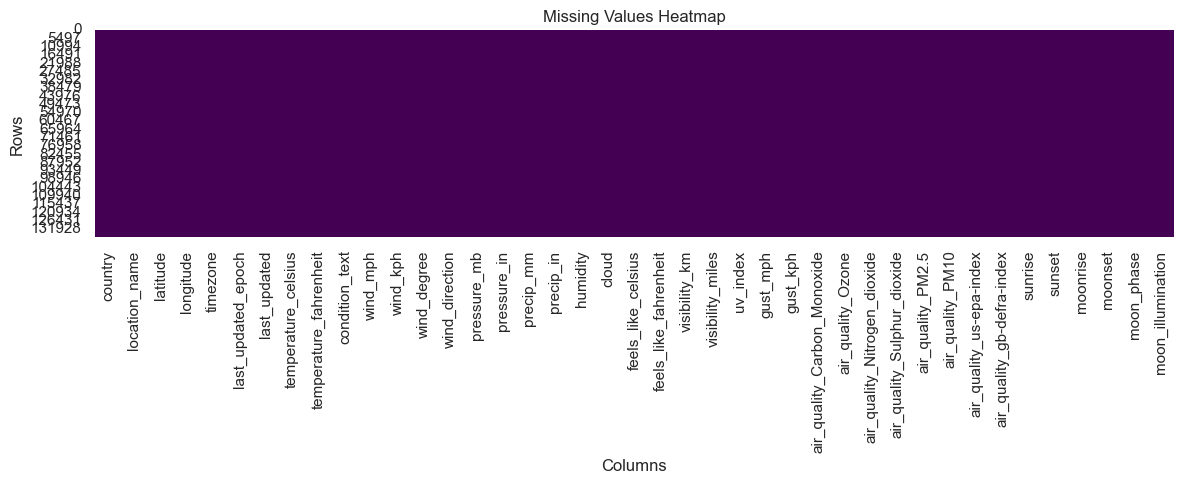

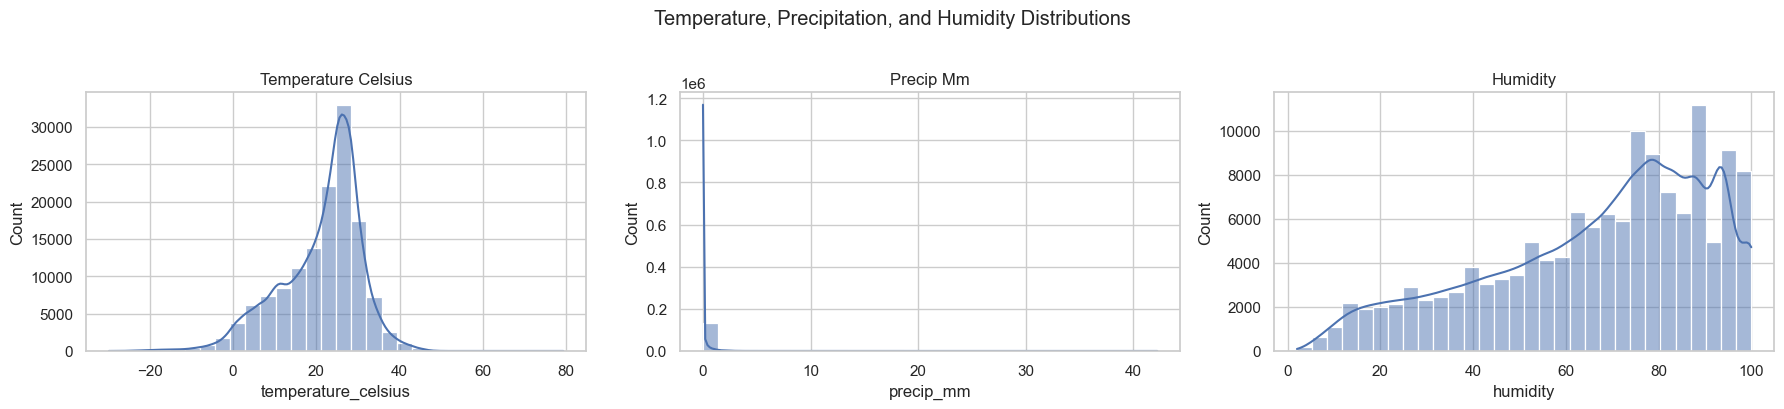

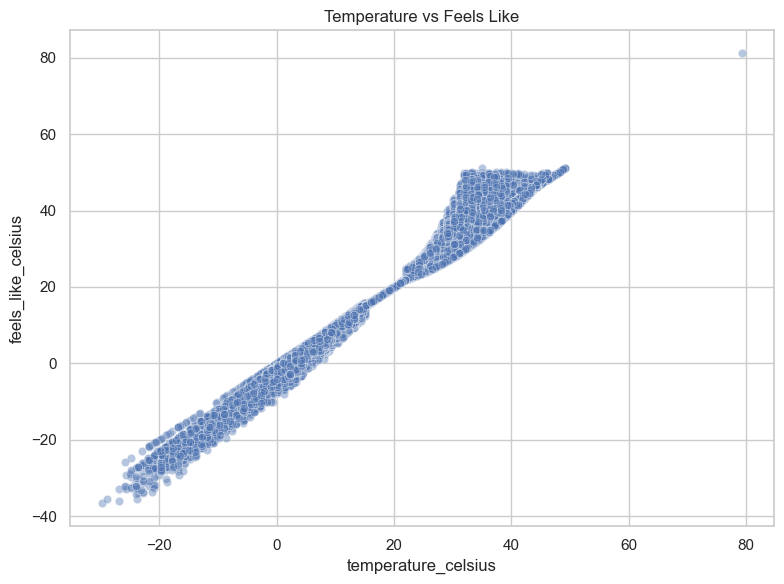

In [4]:
air_quality_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
]

fig_missing = plot_missing_values_heatmap(df)
display(fig_missing)
plt.close(fig_missing)

fig_distribution = plot_numeric_distributions(
    df,
    ["temperature_celsius", "precip_mm", "humidity"],
    title="Temperature, Precipitation, and Humidity Distributions",
)
display(fig_distribution)
plt.close(fig_distribution)

fig_feels_like = plot_temperature_vs_feels_like(df)
display(fig_feels_like)
plt.close(fig_feels_like)


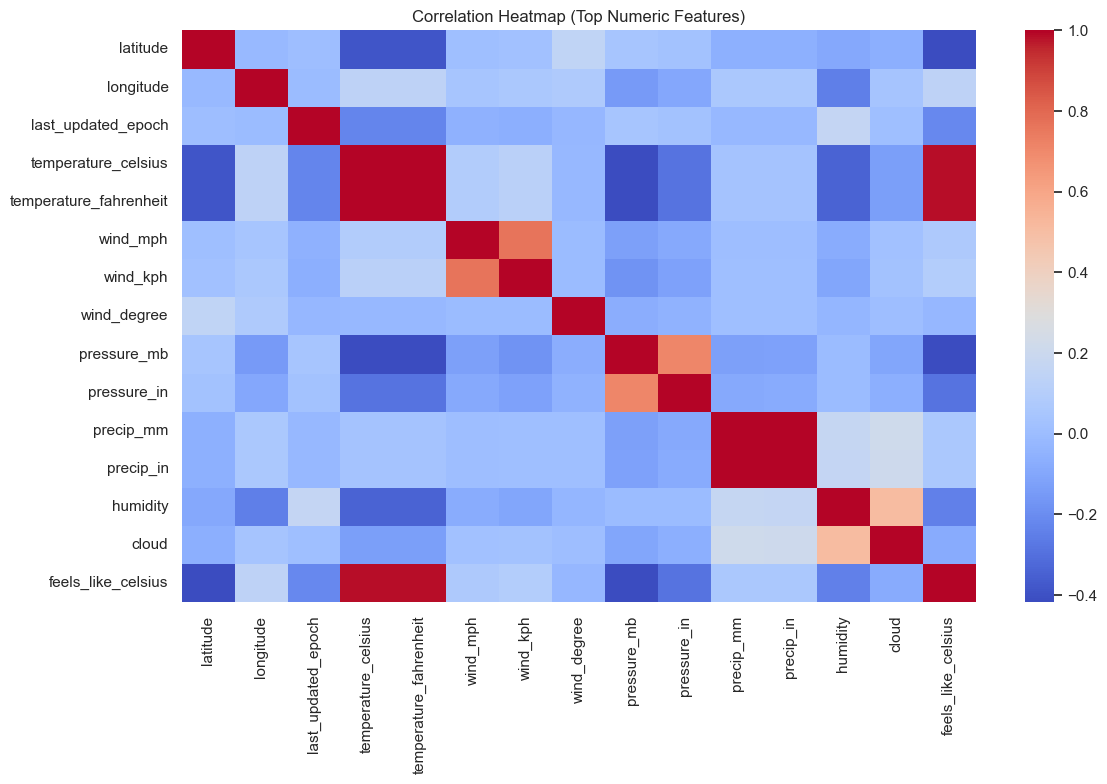

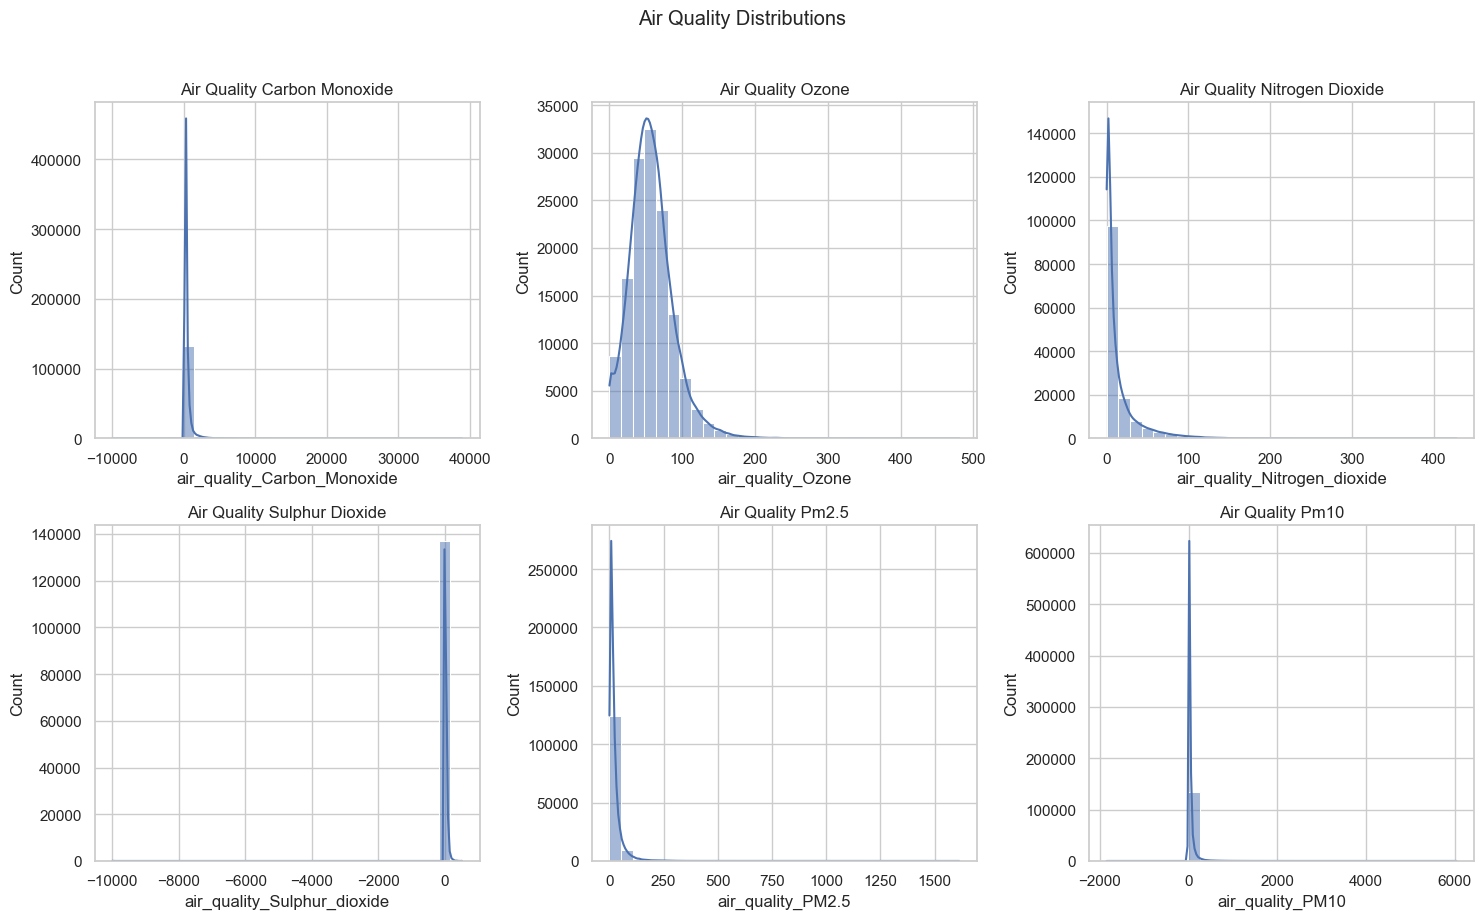

In [5]:
corr_columns = get_numeric_columns(df)[:15]
fig_corr = plot_correlation_heatmap(df, columns=corr_columns, title="Correlation Heatmap (Top Numeric Features)")
display(fig_corr)
save_figure(fig_corr, FIGURES_DIR / "eda_correlation_heatmap.png")
plt.close(fig_corr)

fig_air = plot_air_quality_distributions(df, air_quality_columns)
display(fig_air)
save_figure(fig_air, FIGURES_DIR / "eda_air_quality_distributions.png")
plt.close(fig_air)
